# CS166 – Social Media Bot Detection
## Data Loading & Preprocessing Notebook
**Team 1:** Aaminah Mohammed, Alex Chang, Jumana Ayoub  
**Course:** CS166 Information Security, Spring 2026  
**Instructor:** Professor Chao-Li Tarng

##Section 1: Data loading

In [1]:
#Section 1 loading the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# load data from github
url = "https://raw.githubusercontent.com/aaminahmq/Datafiles/refs/heads/main/CS%20166%20group%20project/bot_detection_data.csv"
df = pd.read_csv(url)

print(f"Dataset loaded successfully!")
print(f"Total rows:    {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dataset loaded successfully!
Total rows:    50000
Total columns: 11


##Section 2 Basic Data Exploration


In [2]:
# Column names and data types
print("Column names and data types:")
print(df.dtypes)

Column names and data types:
User ID            int64
Username          object
Tweet             object
Retweet Count      int64
Mention Count      int64
Follower Count     int64
Verified            bool
Bot Label          int64
Location          object
Created At        object
Hashtags          object
dtype: object


In [3]:
df.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64


In [5]:
# How many bots vs real users?
print("Bot Label counts:")
print(df["Bot Label"].value_counts())
print()
print("(1 = Bot, 0 = Real User)")

Bot Label counts:
Bot Label
1    25018
0    24982
Name: count, dtype: int64

(1 = Bot, 0 = Real User)


## Section 3 Handle Missing Values
The Hashtags column has about 8341 missing values  
This just means those tweets had no hashtags, so we fill the blanks with an empty string instead of leaving them as NaN.


In [6]:
df["Hashtags"] = df["Hashtags"].fillna("")

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
User ID           0
Username          0
Tweet             0
Retweet Count     0
Mention Count     0
Follower Count    0
Verified          0
Bot Label         0
Location          0
Created At        0
Hashtags          0
dtype: int64


##Section 4 Feature Engineering


In [7]:
# Account Age in days
df["Created At"] = pd.to_datetime(df["Created At"])
reference_date = pd.Timestamp("2024-01-01")
df["Account Age (Days)"] = (reference_date - df["Created At"]).dt.days

# Tweet length
df["Tweet Length"] = df["Tweet"].str.len()

# Hashtag count
df["Hashtag Count"] = df["Hashtags"].apply(
    lambda x: len(str(x).split()) if str(x).strip() != "" else 0
)

# Convert Verified True/False -> 1/0
df["Verified"] = df["Verified"].astype(int)

print("New features created successfully!")
df[["Account Age (Days)", "Tweet Length", "Hashtag Count", "Verified"]].head()

New features created successfully!


,Account Age (Days),Tweet Length,Hashtag Count,Verified
0,1329,83,0,0
1,400,77,2,1
2,510,61,2,1
3,869,49,4,1
4,1357,29,2,0


##Section 5 Features for the model

In [8]:
features = [
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "Verified",
    "Account Age (Days)",
    "Tweet Length",
    "Hashtag Count"
]

target = "Bot Label"

X = df[features]
y = df[target]

print("Features selected for the model:")
for f in features:
    print(f"  - {f}")
print(f"\nTarget: {target}  (1 = Bot, 0 = Real User)")

Features selected for the model:
  - Retweet Count
  - Mention Count
  - Follower Count
  - Verified
  - Account Age (Days)
  - Tweet Length
  - Hashtag Count

Target: Bot Label  (1 = Bot, 0 = Real User)


In [9]:
# Summary statistics for our selected features
X.describe().round(2)

,Retweet Count,Mention Count,Follower Count,Verified,Account Age (Days),Tweet Length,Hashtag Count
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00
mean,50.01,2.51,4988.60,0.5,838.24,62.63,2.50
std,29.18,1.71,2878.74,0.5,360.84,16.47,1.71
min,0.00,0.00,0.00,0.0,214.00,23.00,0.00
25%,25.00,1.00,2487.75,0.0,526.00,49.00,1.00
50%,50.00,3.00,4991.50,1.0,836.00,62.00,2.00
75%,75.00,4.00,7471.00,1.0,1153.00,76.00,4.00
max,100.00,5.00,10000.00,1.0,1460.00,118.00,5.00


## Section 6: Train / Test Split
We split the data so that:
- 80% is used to train the model
- 20% is used to test how well the model does on data it has never seen before

random_state=42 makes sure we get the same split every time we run the notebook

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  40000 rows
Test set:      10000 rows


##Section 7 feature scaling

In [11]:
 #scaling the features

scaler = StandardScaler()

# Fit on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print()
print("Data is ready for model training!")

Scaling complete!
X_train_scaled shape: (40000, 7)
X_test_scaled shape:  (10000, 7)

Data is ready for model training!


##Section 8 Data visualizations

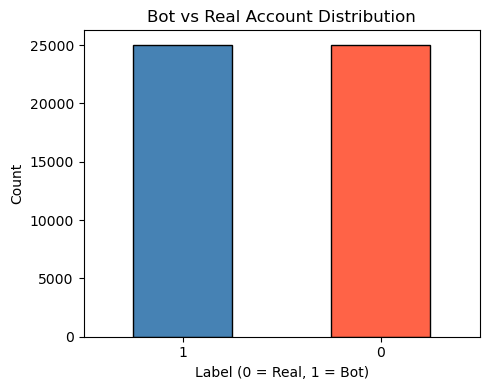

In [12]:
#bot vs real account distributions
plt.figure(figsize=(5, 4))
df["Bot Label"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"],
    edgecolor="black"
)
plt.title("Bot vs Real Account Distribution")
plt.xlabel("Label (0 = Real, 1 = Bot)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

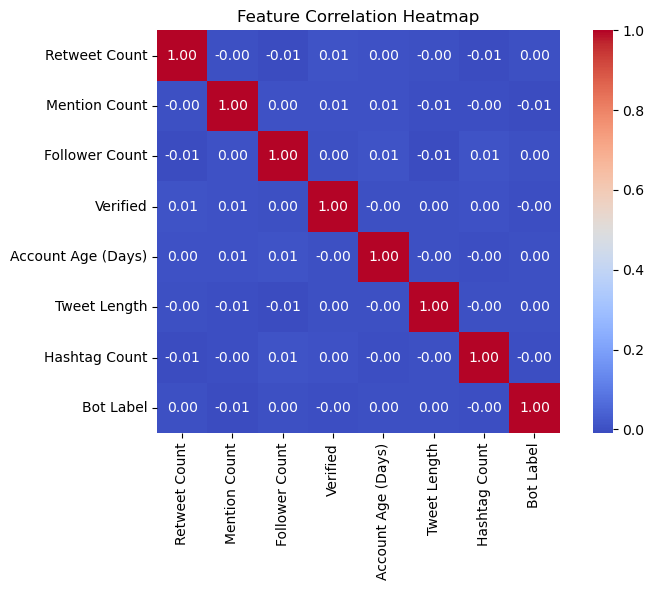

In [13]:
# feature correlation

plt.figure(figsize=(8, 6))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Section 7: The Models

### Random Forest Classifier

--- Model Performance ---
Accuracy Score: 0.5054

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.51      0.51      4968
           1       0.51      0.50      0.50      5032

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



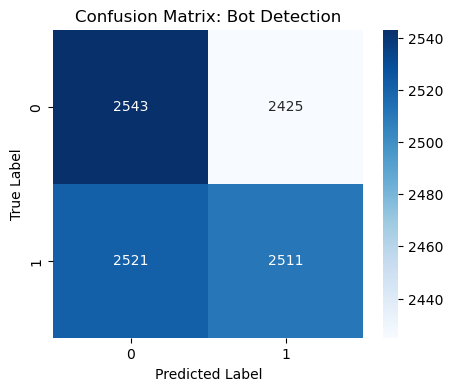

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=500, random_state=42)

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Bot Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

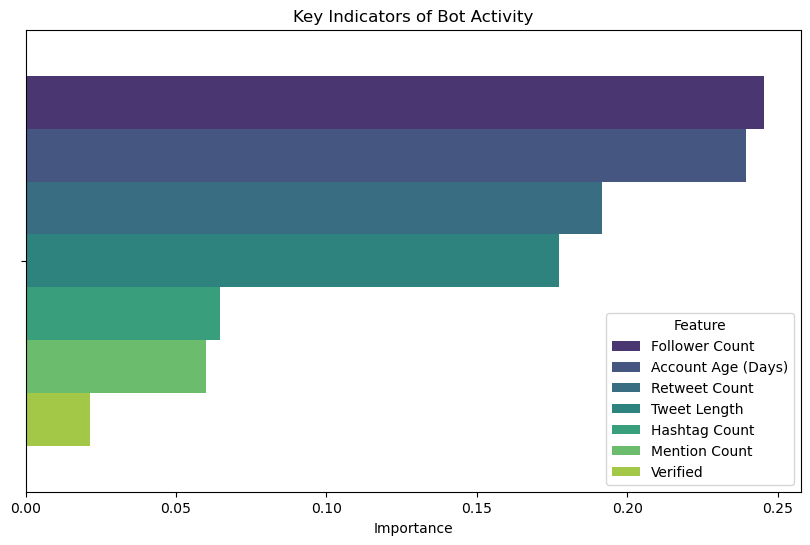

In [15]:
# Extract feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', hue='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Indicators of Bot Activity')
plt.show()

### Linear Regression

--- Model Performance ---
Accuracy Score: 0.5104

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      4968
           1       0.52      0.45      0.48      5032

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



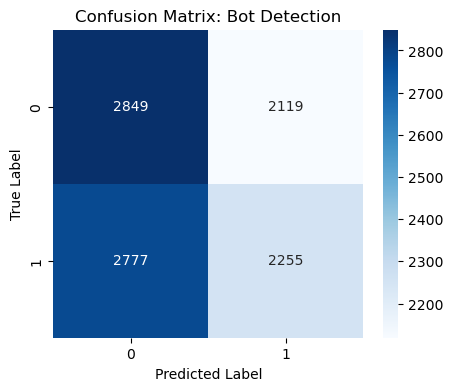

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model
model = LogisticRegression(random_state=42)

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Bot Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###Decision Tree Classifier

--- Decision Tree Performance ---
Accuracy:  0.4937
AUC-ROC:   0.4938

              precision    recall  f1-score   support

           0       0.49      0.44      0.46      4968
           1       0.50      0.55      0.52      5032

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.49     10000
weighted avg       0.49      0.49      0.49     10000



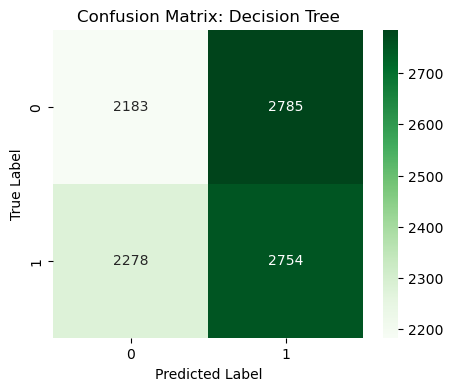

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("--- Decision Tree Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### XGBoost Classifier

In [ ]:
!pip install xgboost #only run this line if xgboost is not already installed in your environment

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
--- XGBoost Performance ---
Accuracy:  0.4985
AUC-ROC:   0.5016

              precision    recall  f1-score   support

           0       0.50      0.50      0.50      4968
           1       0.50      0.50      0.50      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



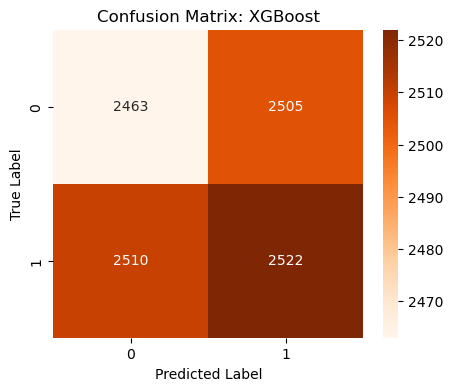

In [ ]:
from xgboost import XGBClassifier

# Train
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("--- XGBoost Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Knearest Neighbor

  K=3  ->  Accuracy: 0.5001
  K=5  ->  Accuracy: 0.4946
  K=7  ->  Accuracy: 0.4942
  K=11  ->  Accuracy: 0.4862

Best K: 3  (Accuracy: 0.5001)

--- KNN Performance (K=3) ---
Accuracy:  0.5001
AUC-ROC:   0.4991

              precision    recall  f1-score   support

           0       0.50      0.50      0.50      4968
           1       0.50      0.50      0.50      5032

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



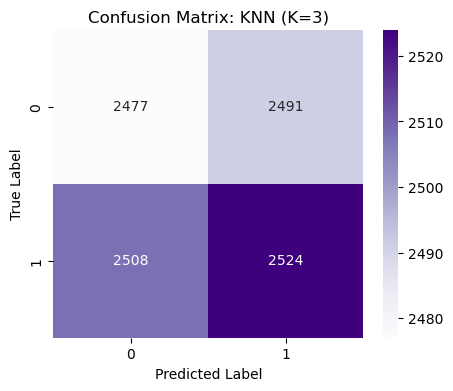

In [23]:
from sklearn.neighbors import KNeighborsClassifier

# Try different values of K
k_values = [3, 5, 7, 11]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    knn_results[k] = acc
    print(f"  K={k}  ->  Accuracy: {acc:.4f}")

best_k = max(knn_results, key=knn_results.get)
print(f"\nBest K: {best_k}  (Accuracy: {knn_results[best_k]:.4f})")

# Train final KNN with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print()
print(f"--- KNN Performance (K={best_k}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Purples")
plt.title(f"Confusion Matrix: KNN (K={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Models Comparison

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Collect all model predictions
models_info = {
    "Logistic Regression": (y_pred_lr  if 'y_pred_lr'  in dir() else None, y_prob_lr  if 'y_prob_lr'  in dir() else None),
    "Random Forest":       (y_pred_rf  if 'y_pred_rf'  in dir() else None, y_prob_rf  if 'y_prob_rf'  in dir() else None),
    "Decision Tree":       (y_pred_dt,  y_prob_dt),
    "XGBoost":             (y_pred_xgb, y_prob_xgb),
    f"KNN (K={best_k})":  (y_pred_knn, y_prob_knn),
}

# Try to recover LR and RF predictions if they were saved under different names
# (the existing notebook may have used 'y_pred' and 'model')
try:
    y_pred_lr
except NameError:
    try:
        y_pred_lr = y_pred   # fallback to generic name used in existing notebook
        y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]
        models_info["Logistic Regression"] = (y_pred_lr, y_prob_lr)
    except:
        pass

try:
    y_pred_rf
except NameError:
    pass  # will just show None

rows = []
for name, (preds, probs) in models_info.items():
    if preds is None:
        continue
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1-Score":  round(f1_score(y_test, preds), 4),
        "AUC-ROC":   round(roc_auc_score(y_test, probs), 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("Model Comparison Table:")
print(results_df.to_string())


Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.5104     0.5155  0.4481    0.4795   0.5123
Decision Tree          0.4937     0.4972  0.5473    0.5210   0.4938
XGBoost                0.4985     0.5017  0.5012    0.5014   0.5016
KNN (K=3)              0.5001     0.5033  0.5016    0.5024   0.4991


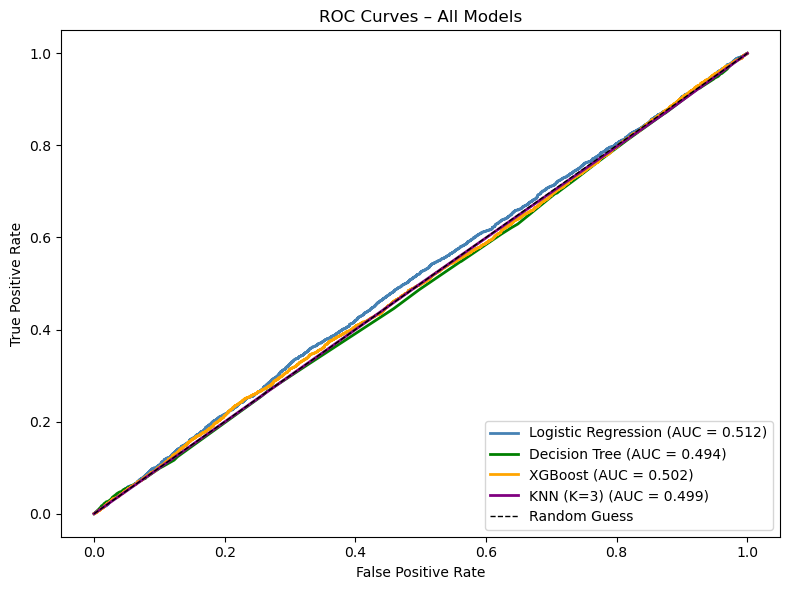

In [25]:
# ROC curves for all models
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

colors = ["steelblue", "tomato", "green", "orange", "purple"]
for (name, (preds, probs)), color in zip(models_info.items(), colors):
    if probs is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()